# M/M/c: интенсивность потока и число каналов
Параметрическое дополнение §7.4. Аналитические показатели применимы при ρ<1.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("MMCQueue.jl"))
using .MMCQueue
include(srcdir("experiment_support.jl"))

mean_interval (generic function with 1 method)

## План эксперимента
Каждый опыт содержит 20000 заявок. Первые 2000 исключаются из клиентских
оценок; интегралы состояния считаются до последнего прибытия, без фазы слива.

In [2]:
arrival_rates = [.3, .6, .9]
capacities = [1, 2, 3, 4]
num_customers, warmup, μ = 20_000, 2_000, .5
summaries, sampled = NamedTuple[], DataFrame[]

(NamedTuple[], DataFrame[])

## Выполнение двенадцати сочетаний
Сохраняются все времена клиентов; для обзорных траекторий — 1001 отсчёт
фактического кусочно-постоянного состояния каждого календаря событий.

In [3]:
for (index, (λ,c)) in enumerate(Iterators.product(arrival_rates,capacities))
    seed = 7000+index
    result = simulate_mmc(; num_customers, num_servers=c, λ, μ, seed)
    observed, theory = queue_summary(result; warmup), erlang_c(λ,μ,c)
    push!(summaries, merge((experiment=index, seed=seed), observed,
        (rho=theory.rho, stable=theory.stable, theory_Wq=theory.Wq,
            theory_W=theory.W, theory_Lq=theory.Lq, theory_L=theory.L,
            theory_p_wait=theory.p_wait)))
    clients = insertcols!(result.customers, 1, :experiment=>index, :λ=>λ, :c=>c)
    CSV.write(datadir("mmc_param_customers.csv"), clients; append=index>1, writeheader=index==1)
    trace = sampled_queue(result.events, last(result.customers.arrival))
    insertcols!(trace, 1, :experiment=>index, :λ=>λ, :c=>c)
    push!(sampled, trace)
end
summary = DataFrame(summaries)
traces = vcat(sampled...)
save_table("mmc_param_summary.csv", summary)
save_table("mmc_param_states.csv", traces)
select(summary, :λ,:c,:rho,:stable,:Wq,:theory_Wq,:utilization,:p_wait,:theory_p_wait)

Row,λ,c,rho,stable,Wq,theory_Wq,utilization,p_wait,theory_p_wait
,Float64,Int64,Float64,Bool,Float64,Float64?,Float64,Float64,Float64?
1,0.3,1,0.6,true,3.18301,3.0,0.603821,0.605167,0.6
2,0.6,1,1.2,false,3837.5,missing,1.0,1.0,missing
3,0.9,1,1.8,false,9690.75,missing,1.0,1.0,missing
4,0.3,2,0.3,true,0.208983,0.197802,0.302832,0.147056,0.138462
5,0.6,2,0.6,true,1.15209,1.125,0.602657,0.453833,0.45
6,0.9,2,0.9,true,9.12894,8.52632,0.896747,0.847278,0.852632
7,0.3,3,0.2,true,0.0201247,0.0205479,0.200957,0.0253333,0.0246575
8,0.6,3,0.4,true,0.147471,0.156863,0.40158,0.1365,0.141176
9,0.9,3,0.6,true,0.567654,0.591241,0.59581,0.347167,0.354745


## Среднее ожидание: имитация и формула Эрланга C

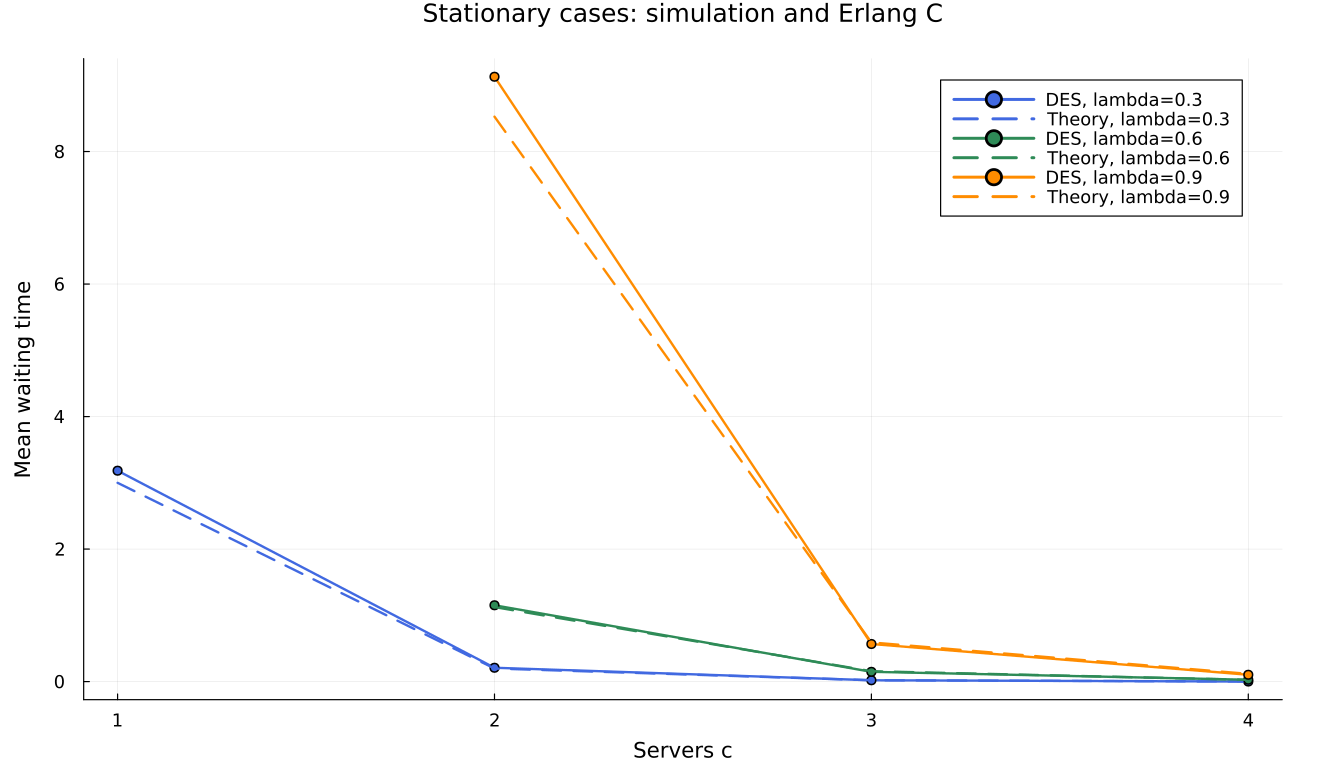

In [4]:
p_wait = plot(; xlabel="Servers c", ylabel="Mean waiting time", title="Stationary cases: simulation and Erlang C")
for (index, λ) in enumerate(arrival_rates)
    rows = filter(row->row.λ==λ && row.stable, summary)
    color=[:royalblue,:seagreen,:darkorange][index]
    plot!(p_wait, rows.c, rows.Wq; marker=:circle, color, label="DES, lambda=$λ")
    plot!(p_wait, rows.c, rows.theory_Wq; linestyle=:dash, color, label="Theory, lambda=$λ")
end
savefig(p_wait, imagepath("03-plot.png"))
display(p_wait)

## Загрузка и проверка стационарных балансов

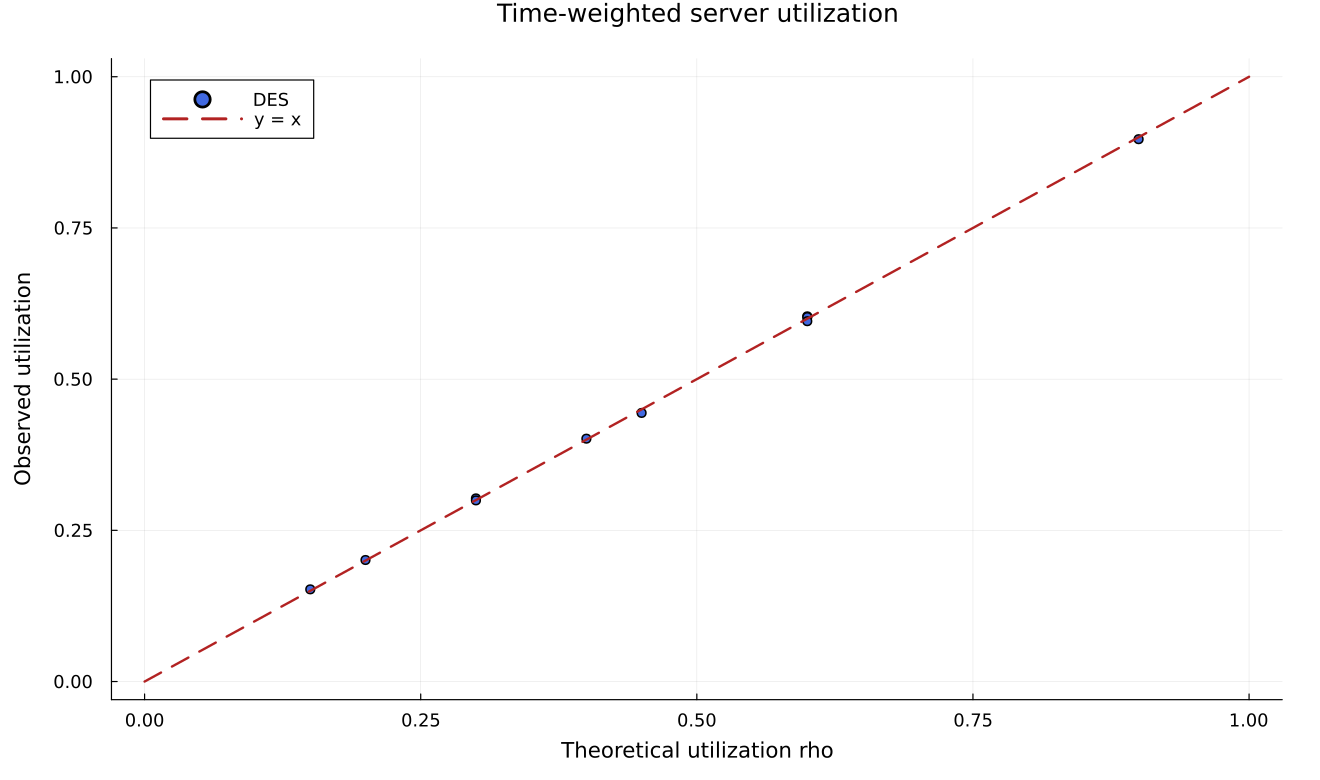

Row,λ,c,Lq,theory_Lq,little_Lq_residual,little_L_residual
,Float64,Int64,Float64,Float64?,Float64,Float64
1,0.3,1,0.946819,0.9,-0.00808512,-0.0132034
2,0.3,2,0.0627922,0.0593407,9.72142e-5,0.000941937
3,0.6,2,0.693545,0.675,0.00228847,0.00626185
4,0.9,2,8.29585,7.67368,0.0798019,0.0964987
5,0.3,3,0.00607913,0.00616438,4.17298e-5,0.0041771
6,0.6,3,0.0891783,0.0941176,0.000695532,0.0100173
7,0.9,3,0.507714,0.532117,-0.00317429,-0.0138015
8,0.3,4,0.000294218,0.000615198,4.62183e-6,0.00958314
9,0.6,4,0.0166857,0.0158785,-3.06311e-5,-0.00219437


In [5]:
stable = filter(:stable=>identity, summary)
p_busy = scatter(stable.rho, stable.utilization; xlabel="Theoretical utilization rho",
    ylabel="Observed utilization", label="DES", color=:royalblue,
    title="Time-weighted server utilization")
plot!(p_busy, [0,1], [0,1]; color=:firebrick, linestyle=:dash, label="y = x")
savefig(p_busy, imagepath("04-plot.png"))
display(p_busy)
select(stable, :λ,:c,:Lq,:theory_Lq,:little_Lq_residual,:little_L_residual)

## Неустойчивые очереди
При λ≥cμ длинный конечный прогон всё ещё завершается после обслуживания всех
клиентов, но стационарного Wq нет. Пустые теоретические значения не заменяются нулями.

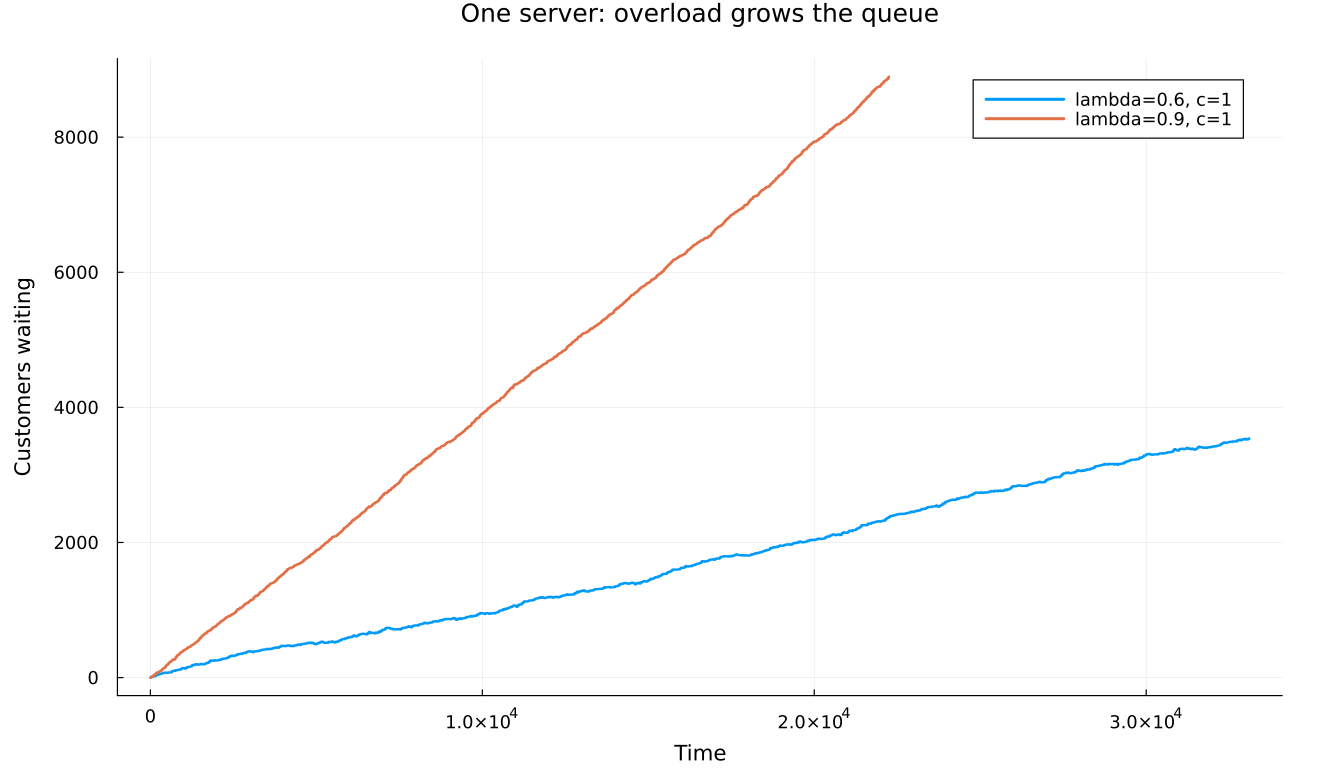

Row,experiment,seed,λ,μ,c,customers,warmup,observed,t0,t1,Wq,W,Lq,L,utilization,p_wait,mean_service,little_Lq_residual,little_L_residual,rho,stable,theory_Wq,theory_W,theory_Lq,theory_L,theory_p_wait
,Int64,Int64,Float64,Float64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Bool,Float64?,Float64?,Float64?,Float64?,Float64?
1,2,7002,0.6,0.5,1,20000,2000,18000,3301.12,33104.7,3837.5,3839.5,1908.52,1909.52,1.0,1.0,1.99637,-393.98,-394.178,1.2,false,missing,missing,missing,missing,missing
2,3,7003,0.9,0.5,1,20000,2000,18000,2237.57,22249.8,9690.75,9692.76,4787.54,4788.54,1.0,1.0,2.0101,-3934.13,-3934.94,1.8,false,missing,missing,missing,missing,missing


In [6]:
p_unstable = plot(; xlabel="Time", ylabel="Customers waiting", title="One server: overload grows the queue")
for λ in [.6,.9]
    rows = filter(row->row.λ==λ && row.c==1, traces)
    plot!(p_unstable, rows.time, rows.queue; label="lambda=$λ, c=1", seriestype=:steppost)
end
savefig(p_unstable, imagepath("05-plot.png"))
display(p_unstable)
filter(:stable=>!, summary)